# Projectile Motion — Piecewise Parabolic Fit

For each launch angle α, the trajectory is modelled as **two separate parabolas**:

- **Arc 1 (ascending):** $y = a_1 x^2 + b_1 x + c_1$ for $x \in [0,\, x_{\text{peak}}]$
- **Arc 2 (descending):** $y = a_2 x^2 + b_2 x + c_2$ for $x \in [x_{\text{peak}},\, x_{\text{end}}]$

The physical motivation is that air drag causes the descending arc to be steeper and compressed compared to the ascending arc, so a single parabola is a poor global fit.

**Outputs per angle:**
- Peak point $(x_{\text{peak}},\, y_{\text{peak}})$ identified
- Equations of Arc 1 and Arc 2 with domain restrictions
- $R^2$ for each arc and overall
- Standard uncertainties in each fitted coefficient ($a$, $b$, $c$)
- Overlay plot: data + both arcs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

"""CONFIGURATION"""
CSV_DIR   = Path('raw_csvs')   # folder containing the per-angle CSVs
SIGMA_XY  = 0.1                       # experimental uncertainty in x and y / cm
ANGLES    = [15, 25, 35, 45, 55, 65, 75]   # degrees

def parabola(x, a, b, c):
    return a * x**2 + b * x + c

def fit_parabola(x, y, sigma_y):
    """
    Fit y = ax^2 + bx + c weighted by 1/sigma_y.
    Returns (popt, perr, r2) where perr are 1-sigma standard uncertainties.
    """
    # Create sigma array for curve_fit; all points have the same uncertainty sigma_y
    sigma = np.full_like(y, sigma_y, dtype=float)
    try:
        # Use curve_fit to find optimal parameters and covariance matrix
        popt, pcov = curve_fit(parabola, x, y, sigma=sigma, absolute_sigma=True)
    except RuntimeError:
        popt, pcov = np.polyfit(x, y, 2, cov=True)
        # Polyfit returns coefficients in order of descending powers, but we want a,b,c
        popt = popt[::-1]
        pcov = pcov[::-1, ::-1]
    
    # Standard uncertainties are sqrt of diagonal elements of covariance matrix
    perr = np.sqrt(np.diag(pcov))
    y_pred = parabola(x, *popt)

    # Calculate R² for the fit
    ss_res = np.sum((y - y_pred)**2) # Residual sum of squares
    ss_tot = np.sum((y - np.mean(y))**2) # Total sum of squares
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Returns optimal parameters, their uncertainties, and R²
    return popt, perr, r2

def find_peak_index(y):
    """
    Return the index of the maximum y value.
    If multiple rows share the maximum, take the first occurrence (ascending side).
    """
    return int(np.argmax(y))

 Angle    peak x    peak y          a1          b1          c1          a2          b2          c2   R2_arc1   R2_arc2   R2_full
----------------------------------------------------------------------------------------------------------------------------------
    15°      8.00      0.80    -0.01072     0.17491     0.00762    -0.01948     0.26439    -0.13278   0.97280   0.97143   0.97269
    25°      7.60      2.00    -0.02138     0.42745    -0.07653    -0.02686     0.47302    -0.07080   0.99417   0.99496   0.99477
    35°     19.60      7.10    -0.01620     0.69043    -0.24198    -0.01475     0.54390     2.19949   0.99841   0.99945   0.99894
    45°     21.20     12.00    -0.02098     1.01476    -0.14353    -0.02848     1.31085    -3.05225   0.99977   0.99992   0.99985
    55°     19.60     15.00    -0.03421     1.43908    -0.12739    -0.05006     2.00879    -5.05864   0.99983   0.99979   0.99981
    65°     15.60     17.20    -0.06287     2.06163     0.24252    -0.07881     2.63607   

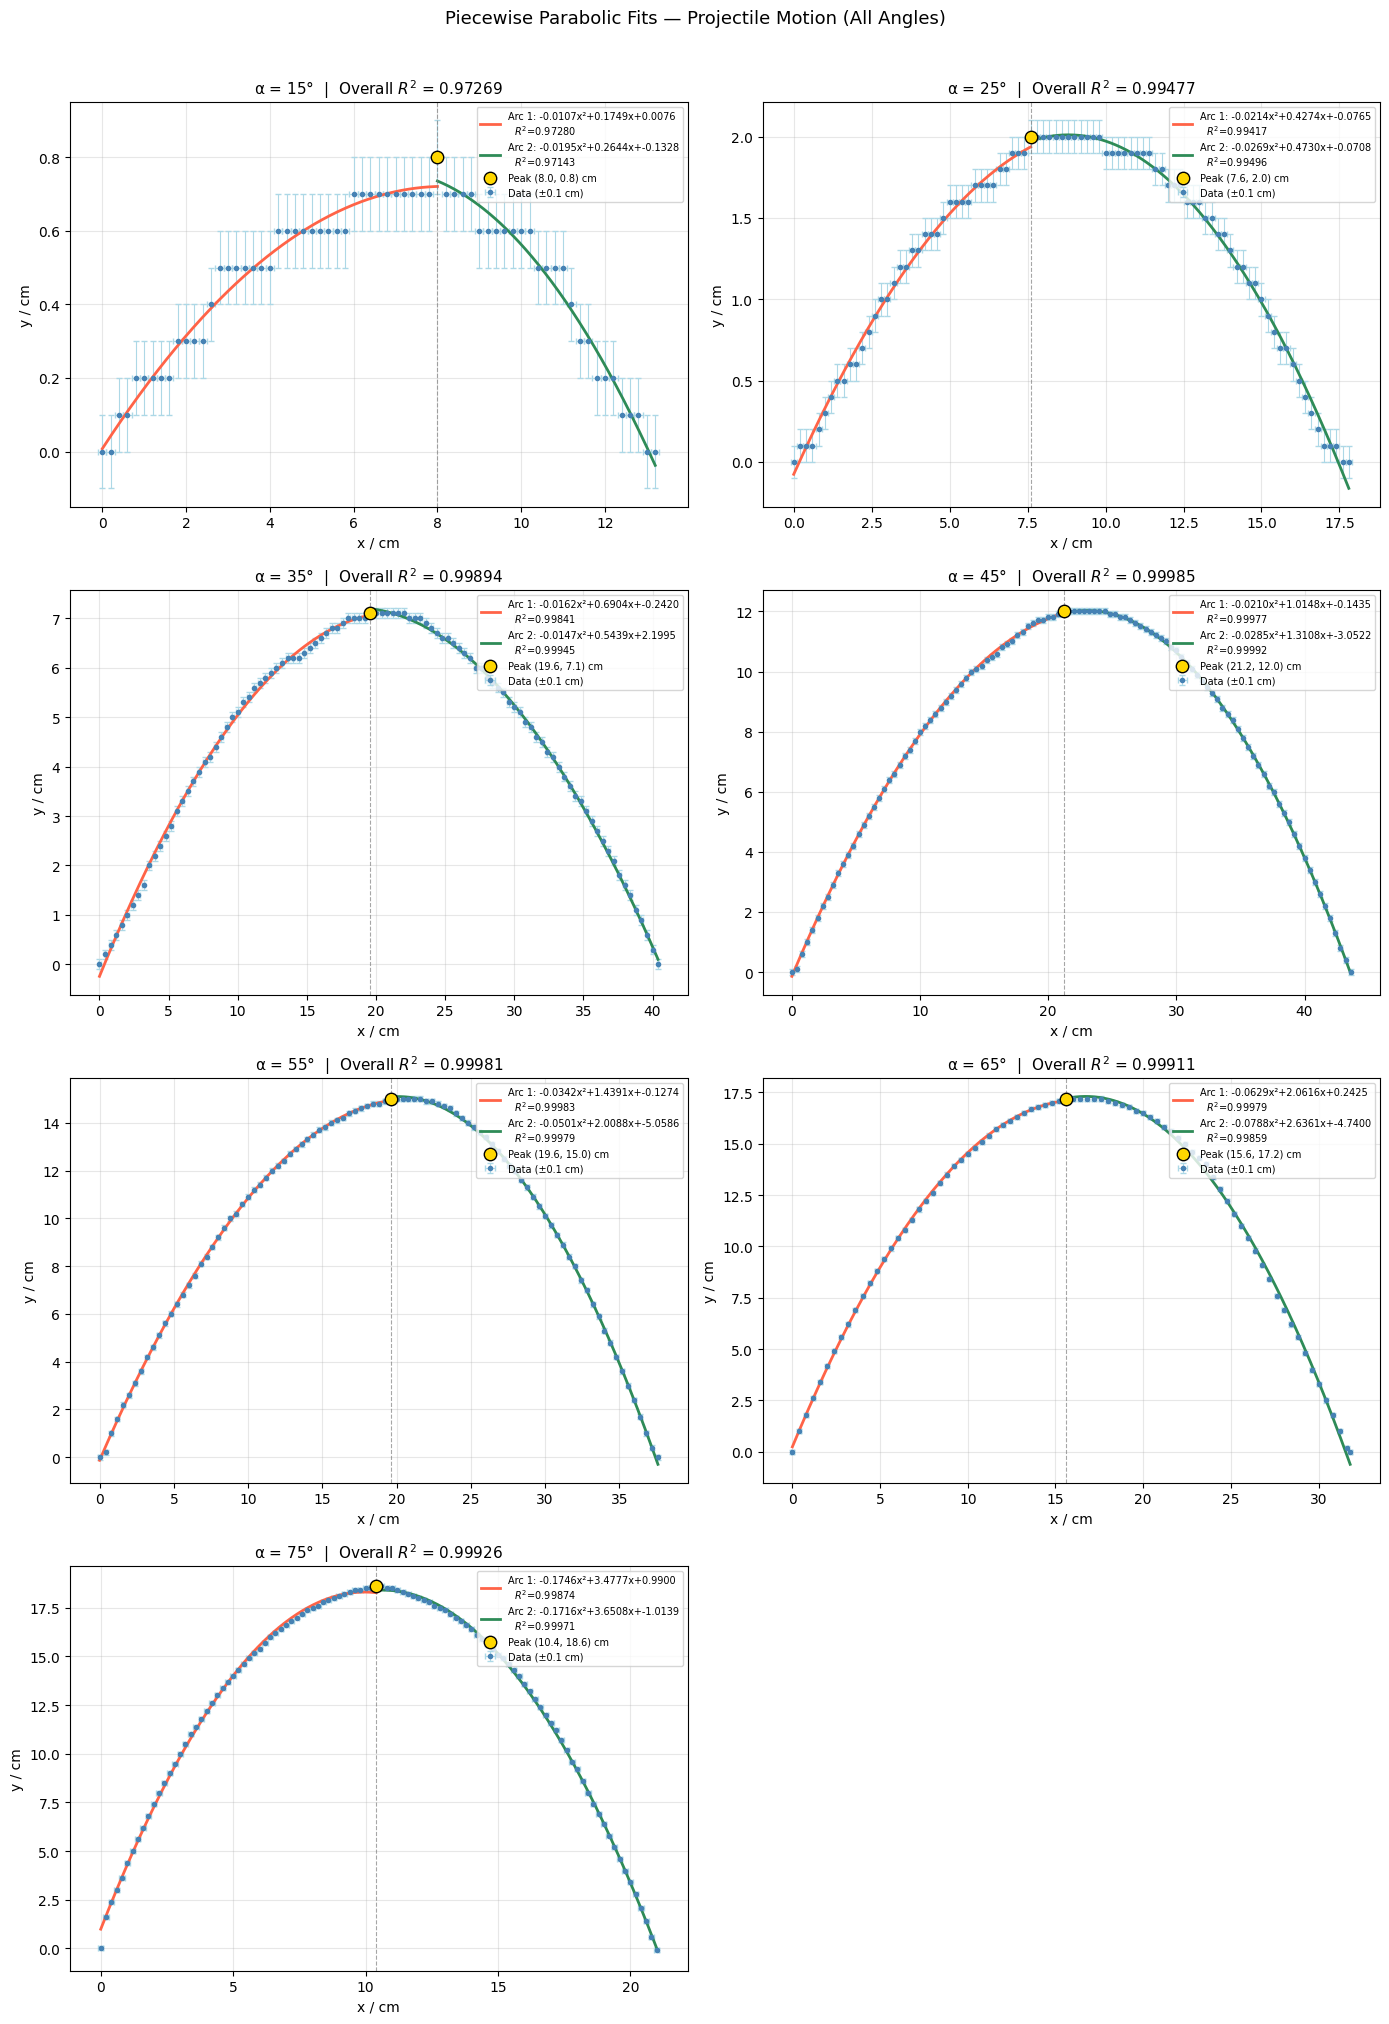


Plot saved to parabolic_fit.png


In [2]:
# Set up figure for all angles
fig_all, axes_all = plt.subplots(4, 2, figsize=(14, 20))
axes_all = axes_all.flatten()

results = {}

print(f"{'Angle':>6}  {'peak x':>8}  {'peak y':>8}  "
      f"{'a1':>10}  {'b1':>10}  {'c1':>10}  "
      f"{'a2':>10}  {'b2':>10}  {'c2':>10}  "
      f"{'R2_arc1':>8}  {'R2_arc2':>8}  {'R2_full':>8}")
print('-' * 130)

"""MAIN ANALYSIS LOOP"""
for idx, angle in enumerate(ANGLES):
    csv_path = CSV_DIR / f'alpha_{angle}deg.csv'
    df = pd.read_csv(csv_path)
    x = df['x_cm'].to_numpy(dtype=float)
    y = df['y_cm'].to_numpy(dtype=float)

    # 1. Find peak index (maximum y) to split ascending/descending arcs
    peak_idx = find_peak_index(y)
    x_peak, y_peak = x[peak_idx], y[peak_idx]

    # 2. Split data into two arcs: Arc 1 (ascending) and Arc 2 (descending)
    x1, y1 = x[:peak_idx + 1], y[:peak_idx + 1]
    x2, y2 = x[peak_idx:],     y[peak_idx:]

    if len(x1) < 3:
        print(f"α={angle}°: Arc 1 has only {len(x1)} points — skipping.")
        continue
    if len(x2) < 3:
        print(f"α={angle}°: Arc 2 has only {len(x2)} points — skipping.")
        continue

    # 3. Fit parabolas to each arc and calculate R²
    popt1, perr1, r2_1 = fit_parabola(x1, y1, SIGMA_XY)
    popt2, perr2, r2_2 = fit_parabola(x2, y2, SIGMA_XY)

    # Overall R² across full dataset using piecewise prediction
    y_pred_full = np.concatenate([
        parabola(x1, *popt1),
        parabola(x2[1:], *popt2)   # skip shared peak to avoid double-counting
    ])
    ss_res_full = np.sum((y - y_pred_full)**2)
    ss_tot_full = np.sum((y - np.mean(y))**2)
    r2_full = 1 - ss_res_full / ss_tot_full if ss_tot_full > 0 else np.nan

    # 4. Store results for summary table
    results[angle] = dict(
        x_peak=x_peak, y_peak=y_peak,
        a1=popt1[0], b1=popt1[1], c1=popt1[2],
        sa1=perr1[0], sb1=perr1[1], sc1=perr1[2],
        a2=popt2[0], b2=popt2[1], c2=popt2[2],
        sa2=perr2[0], sb2=perr2[1], sc2=perr2[2],
        r2_arc1=r2_1, r2_arc2=r2_2, r2_full=r2_full,
        x_start=x[0], x_end=x[-1]
    )

    print(f"{angle:>6}°  "
          f"{x_peak:>8.2f}  {y_peak:>8.2f}  "
          f"{popt1[0]:>10.5f}  {popt1[1]:>10.5f}  {popt1[2]:>10.5f}  "
          f"{popt2[0]:>10.5f}  {popt2[1]:>10.5f}  {popt2[2]:>10.5f}  "
          f"{r2_1:>8.5f}  {r2_2:>8.5f}  {r2_full:>8.5f}")

    # 5. Plotting
    ax = axes_all[idx]

    # Data with error bars
    ax.errorbar(x, y, xerr=SIGMA_XY, yerr=SIGMA_XY,
                fmt='o', ms=3, color='steelblue', ecolor='lightblue',
                elinewidth=0.8, capsize=2, label='Data (±0.1 cm)', zorder=2)

    # Arc 1 fit curve
    x1_plot = np.linspace(x1[0], x1[-1], 300)
    ax.plot(x1_plot, parabola(x1_plot, *popt1), '-', color='tomato', lw=2,
            label=f'Arc 1: {popt1[0]:.4f}x²+{popt1[1]:.4f}x+{popt1[2]:.4f}\n'
                  f'  $R^2$={r2_1:.5f}')

    # Arc 2 fit curve
    x2_plot = np.linspace(x2[0], x2[-1], 300)
    ax.plot(x2_plot, parabola(x2_plot, *popt2), '-', color='seagreen', lw=2,
            label=f'Arc 2: {popt2[0]:.4f}x²+{popt2[1]:.4f}x+{popt2[2]:.4f}\n'
                  f'  $R^2$={r2_2:.5f}')

    # Peak marker
    ax.axvline(x_peak, color='grey', lw=0.8, ls='--', alpha=0.7)
    ax.scatter([x_peak], [y_peak], color='gold', edgecolors='black', s=80,
               zorder=5, label=f'Peak ({x_peak:.1f}, {y_peak:.1f}) cm')

    ax.set_title(f'α = {angle}°  |  Overall $R^2$ = {r2_full:.5f}', fontsize=11)
    ax.set_xlabel('x / cm')
    ax.set_ylabel('y / cm')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

# Hide unused subplot
axes_all[-1].set_visible(False)

# Final layout adjustments and save figure
fig_all.suptitle('Piecewise Parabolic Fits — Projectile Motion (All Angles)', fontsize=13, y=1.01)
fig_all.tight_layout()
plt.savefig('parabolic_fit.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nPlot saved to parabolic_fit.png')

## Detailed Results Table

For each angle, both parabolic arcs are printed with:
- Coefficient values and **1σ standard uncertainties**
- Domain restrictions
- R² for each arc

In [3]:
rows = []
for angle in ANGLES:
    if angle not in results:
        continue
    r = results[angle]
    rows.append({
        'alpha_deg': angle,
        'x_peak_cm': r['x_peak'],   'y_peak_cm': r['y_peak'],
        'a1': r['a1'], 'sig_a1': r['sa1'],
        'b1': r['b1'], 'sig_b1': r['sb1'],
        'c1': r['c1'], 'sig_c1': r['sc1'],
        'R2_arc1': r['r2_arc1'],
        'a2': r['a2'], 'sig_a2': r['sa2'],
        'b2': r['b2'], 'sig_b2': r['sb2'],
        'c2': r['c2'], 'sig_c2': r['sc2'],
        'R2_arc2': r['r2_arc2'],
        'R2_full': r['r2_full'],
    })

summary_df = pd.DataFrame(rows).set_index('alpha_deg')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.5f}'.format)
display(summary_df)

summary_df.to_csv('parabolic_summary.csv')
print('Summary saved to parabolic_summary.csv')

,x_peak_cm,y_peak_cm,a1,sig_a1,b1,sig_b1,c1,sig_c1,R2_arc1,a2,sig_a2,b2,sig_b2,c2,sig_c2,R2_arc2,R2_full
alpha_deg,,,,,,,,,,,,,,,,,
15,8.00000,0.80000,-0.01072,0.00312,0.17491,0.02582,0.00762,0.04466,0.97280,-0.01948,0.00889,0.26439,0.18877,-0.13278,0.98569,0.97143,0.97269
25,7.60000,2.00000,-0.02138,0.00354,0.42745,0.02781,-0.07653,0.04568,0.99417,-0.02686,0.00172,0.47302,0.04398,-0.07080,0.26903,0.99496,0.99477
35,19.60000,7.10000,-0.01620,0.00047,0.69043,0.00962,-0.24198,0.04078,0.99841,-0.01475,0.00041,0.54390,0.02473,2.19949,0.36061,0.99945,0.99894
45,21.20000,12.00000,-0.02098,0.00039,1.01476,0.00859,-0.14353,0.03936,0.99977,-0.02848,0.00034,1.31085,0.02226,-3.05225,0.35069,0.99992,0.99985
55,19.60000,15.00000,-0.03421,0.00047,1.43908,0.00962,-0.12739,0.04078,0.99983,-0.05006,0.00058,2.00879,0.03358,-5.05864,0.46899,0.99979,0.99981
65,15.60000,17.20000,-0.06287,0.00083,2.06163,0.01339,0.24252,0.04516,0.99979,-0.07881,0.00074,2.63607,0.03534,-4.73997,0.40862,0.99859,0.99911
75,10.40000,18.60000,-0.17459,0.00164,3.47765,0.01765,0.99003,0.03970,0.99874,-0.17155,0.00157,3.65078,0.04939,-1.01391,0.37746,0.99971,0.99926


Summary saved to parabolic_summary.csv


---

# Aristotelian Model — Three-Phase Piecewise Fit

The 1592 artillery manual (Fig. 4.1) describes projectile motion as three distinct phases:

| Phase | Name | Mathematical model |
|-------|------|--------------------|
| 1 | **Violent motion** | Straight line: $y = m_1 x + c_1$ |
| 2 | **Mixed motion** | Continuity-constrained parabola: $y = a_2(x-x_{T1})^2 + b_2(x-x_{T1}) + y_{T1}$ |
| 3 | **Natural motion** | Vertical drop: $x = x_{T2}$ (undefined gradient) |

**Continuity enforcement:**
- At $x_{T1}$: Phase 2 is parameterised about $(x_{T1},\,y_{T1})$ so $y(x_{T1}^-) = y(x_{T1}^+) = y_{T1}$ exactly (hard constraint).
- At $x_{T2}$: Phase 3 (the vertical line) begins at the point $(x_{T2},\,y_{T2})$ where Phase 2 ends — naturally continuous.

**Transition-point search:** $x_{T1}$ and $x_{T2}$ are found by exhaustive grid search over all valid index pairs $(i_1, i_2)$, minimising:
$$\text{cost} = \underbrace{\text{SS}_{\text{res}}^{(1)}}_\text{phase 1 } y\text{-residuals} + \underbrace{\text{SS}_{\text{res}}^{(2)}}_\text{phase 2 } y\text{-residuals} + \underbrace{\sum_j(x_j - x_{T2})^2}_\text{phase 3 } x\text{-deviation}$$

**On overall $R^2$:** Since Phase 3 predicts $x = x_{T2}$ (no $y$-from-$x$ relationship), it cannot generate $y$-predictions in the usual sense. For a fair comparison with the parabolic models, Phase 3 is assigned the constant prediction $\hat{y} = y_{T2}$ (the $y$-value where the ball enters vertical fall). The resulting $R^2$ penalises the model for the descending $y$ values it cannot explain.

**Spread of $x$ in Phase 3** ($\Delta x_{P3}$): how far $x$ actually travels after $x_{T2}$. In a true Aristotelian trajectory this would be zero; a large value shows the model fails in the final phase.

In [4]:
# Helper: evaluate the continuity-constrained Phase 2 model

def eval_p2(x, a2, b2_s, x_t1, y_t1):
    """Phase 2 model anchored at (x_t1, y_t1): y = a2*(x-x_t1)^2 + b2_s*(x-x_t1) + y_t1."""
    return a2 * (x - x_t1)**2 + b2_s * (x - x_t1) + y_t1


def fit_linear(x, y, sigma_y):
    """
    Fit y = mx + c weighted by 1/sigma_y.
    Returns (popt, perr, r2) where perr are 1-sigma standard uncertainties.
    """
    sigma = np.full_like(y, sigma_y, dtype=float)
    try:
        popt, pcov = curve_fit(linear_func, x, y, sigma=sigma, absolute_sigma=True)
    except RuntimeError:
        p = np.polyfit(x, y, 1)
        popt = np.array([p[0], p[1]])
        pcov  = np.diag([1e-10, 1e-10])
    perr  = np.sqrt(np.diag(pcov))
    y_pred = linear_func(x, *popt)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return popt, perr, r2


def linear_func(x, m, c):
    return m * x + c


def fit_aristotelian(x, y, sigma_y):
    """
    Fit the three-phase Aristotelian model to trajectory (x, y).

    Phase 1 — Violent (linear):    y = m1*x + c1                          x ∈ [x[0],  x_T1]
    Phase 2 — Mixed   (quadratic): y = a2*(x-x_T1)^2 + b2*(x-x_T1) + y_T1  x ∈ [x_T1, x_T2]
    Phase 3 — Natural (vertical):  x = x_T2  (undefined gradient)          x ∈ {x_T2}

    Continuity is hard-enforced at x_T1 by parameterising Phase 2 about (x_T1, y_T1).
    Continuity at x_T2 is natural: Phase 3 starts where Phase 2 ends.

    Transition indices (i1, i2) are found by exhaustive grid search minimising
    Phase-1 y-residuals + Phase-2 y-residuals + Phase-3 x-deviations from x_T2.

    Returns a dict of parameters, uncertainties, R² values, and metadata;
    or None if the trajectory is too short to segment.
    """
    n        = len(x)
    peak_idx = int(np.argmax(y))
    min_seg  = max(3, n // 12)   # minimum points per segment

    best_cost = np.inf
    best_ij   = None

    # Bounds: violent must end before peak; natural must start at or after peak
    i1_hi = min(peak_idx - 1, n - 2 * min_seg - 1)
    i2_hi = n - min_seg - 1

    if i1_hi < min_seg or i2_hi < peak_idx:
        return None

    for i1 in range(min_seg, i1_hi + 1):
        s1x, s1y = x[:i1 + 1], y[:i1 + 1]
        p1    = np.polyfit(s1x, s1y, 1)
        ss1   = np.sum((s1y - np.polyval(p1, s1x))**2)
        x_t1  = x[i1]
        y_t1  = np.polyval(p1, x_t1)   # predicted y at transition (continuous)

        for i2 in range(max(i1 + min_seg, peak_idx), i2_hi + 1):
            s2x, s2y = x[i1:i2 + 1], y[i1:i2 + 1]
            dx2  = s2x - x_t1
            # Constrained lstsq: fit (y - y_t1) = a*dx^2 + b*dx  (no intercept → continuity)
            A    = np.column_stack([dx2**2, dx2])
            ab, _, _, _ = np.linalg.lstsq(A, s2y - y_t1, rcond=None)
            ss2  = np.sum((s2y - (y_t1 + A @ ab))**2)

            # Phase 3: x should equal x[i2]; cost = sum of squared x-deviations
            ss3  = np.sum((x[i2:] - x[i2])**2)

            cost = ss1 + ss2 + ss3
            if cost < best_cost:
                best_cost = cost
                best_ij   = (i1, i2)

    if best_ij is None:
        return None

    i1, i2    = best_ij
    s1x, s1y  = x[:i1 + 1],   y[:i1 + 1]
    s2x, s2y  = x[i1:i2 + 1], y[i1:i2 + 1]
    s3x, s3y  = x[i2:],        y[i2:]
    x_t1, x_t2 = x[i1], x[i2]

    # Final Phase 1 fit, unconstrained with 2 free parameters
    popt1, perr1, r2_1 = fit_linear(s1x, s1y, sigma_y)
    y_t1 = linear_func(x_t1, *popt1)

    # Final Phase 2 fit, constrained to be continuous with Phase 1 at (x_t1, y_t1)
    def phase2_model(xd, a, b):
        return a * (xd - x_t1)**2 + b * (xd - x_t1) + y_t1

    sigma2 = np.full_like(s2y, sigma_y)
    try:
        popt2, pcov2 = curve_fit(phase2_model, s2x, s2y, sigma=sigma2, absolute_sigma=True)
    except RuntimeError:
        dx2  = s2x - x_t1
        A    = np.column_stack([dx2**2, dx2])
        ab, _, _, _ = np.linalg.lstsq(A, s2y - y_t1, rcond=None)
        popt2 = ab;  pcov2 = np.diag([1e-10, 1e-10])
    perr2 = np.sqrt(np.diag(pcov2))
    a2, b2_s = popt2
    y2_pred  = phase2_model(s2x, a2, b2_s)
    ss_res2  = np.sum((s2y - y2_pred)**2)
    ss_tot2  = np.sum((s2y - np.mean(s2y))**2)
    r2_2     = 1 - ss_res2 / ss_tot2 if ss_tot2 > 0 else np.nan
    # y where ball enters vertical fall
    y_t2     = phase2_model(x_t2, a2, b2_s) 

    # Phase 3 diagnostics (no free parameters)
    # x should be constant at x_t2; Δx_P3 measures how much it actually moves
    x_spread_p3 = float(np.max(s3x) - np.min(s3x))

    # Overall R²: Phase 3 assigned constant prediction y_hat = y_t
    y_pred_full = np.concatenate([
        linear_func(s1x,      *popt1),
        phase2_model(s2x[1:], a2, b2_s),
        np.full(max(len(s3y) - 1, 0), y_t2)
    ])
    ss_res_full = np.sum((y - y_pred_full)**2)
    ss_tot_full = np.sum((y - np.mean(y))**2)
    r2_full     = 1 - ss_res_full / ss_tot_full if ss_tot_full > 0 else np.nan

    return dict(
        i1=i1, i2=i2,
        x_t1=x_t1, y_t1=y_t1, x_t2=x_t2, y_t2=y_t2,
        # Phase 1
        m1=popt1[0], c1=popt1[1], sm1=perr1[0], sc1=perr1[1],
        # Phase 2 (continuity form: y = a2*(x-x_t1)^2 + b2_s*(x-x_t1) + y_t1)
        a2=a2, b2_s=b2_s, sa2=perr2[0], sb2_s=perr2[1],
        # Phase 3
        x_spread_p3=x_spread_p3,
        # Goodness-of-fit
        r2_phase1=r2_1, r2_phase2=r2_2, r2_full=r2_full,
        x_start=x[0], x_end=x[-1]
    )


# Run for all angles and print compact summary

results_aris = {} 

print(f"{'Angle':>6}  {'x_T1':>6}  {'x_T2':>6}  {'Δx_P3':>7}  "
      f"{'m1':>9}  {'a2':>10}  "
      f"{'R2_P1':>8}  {'R2_P2':>8}  {'R2_full':>8}")
print('-' * 95)

for angle in ANGLES:
    csv_path = CSV_DIR / f'alpha_{angle}deg.csv'
    df       = pd.read_csv(csv_path)
    x        = df['x_cm'].to_numpy(dtype=float)
    y        = df['y_cm'].to_numpy(dtype=float)

    res = fit_aristotelian(x, y, SIGMA_XY)
    if res is None:
        print(f"{angle:>6}°  [insufficient data for 3-phase fit]")
        continue

    results_aris[angle] = res

    print(f"{angle:>6}°  {res['x_t1']:>6.1f}  {res['x_t2']:>6.1f}  "
          f"{res['x_spread_p3']:>7.2f}  "
          f"{res['m1']:>9.4f}  {res['a2']:>10.5f}  "
          f"{res['r2_phase1']:>8.5f}  {res['r2_phase2']:>8.5f}  "
          f"{res['r2_full']:>8.5f}")

 Angle    x_T1    x_T2    Δx_P3         m1          a2     R2_P1     R2_P2   R2_full
-----------------------------------------------------------------------------------------------
    15°     2.6    12.2     1.00     0.1341    -0.01767   0.90867   0.89590   0.92359
    25°     2.0    16.4     1.40     0.3273    -0.02797   0.96357   0.99223   0.97389
    35°     7.2    37.2     3.20     0.5548    -0.01784   0.99833   0.99583   0.97807
    45°     4.8    40.0     3.60     0.9176    -0.02474   0.99678   0.99409   0.95424
    55°     7.2    34.8     2.80     1.1860    -0.04253   0.99527   0.98769   0.96040
    65°     2.4    29.6     2.20     2.0268    -0.06702   0.99816   0.99223   0.96660
    75°     1.6    19.4     1.60     3.6167    -0.15822   0.97857   0.99914   0.96869


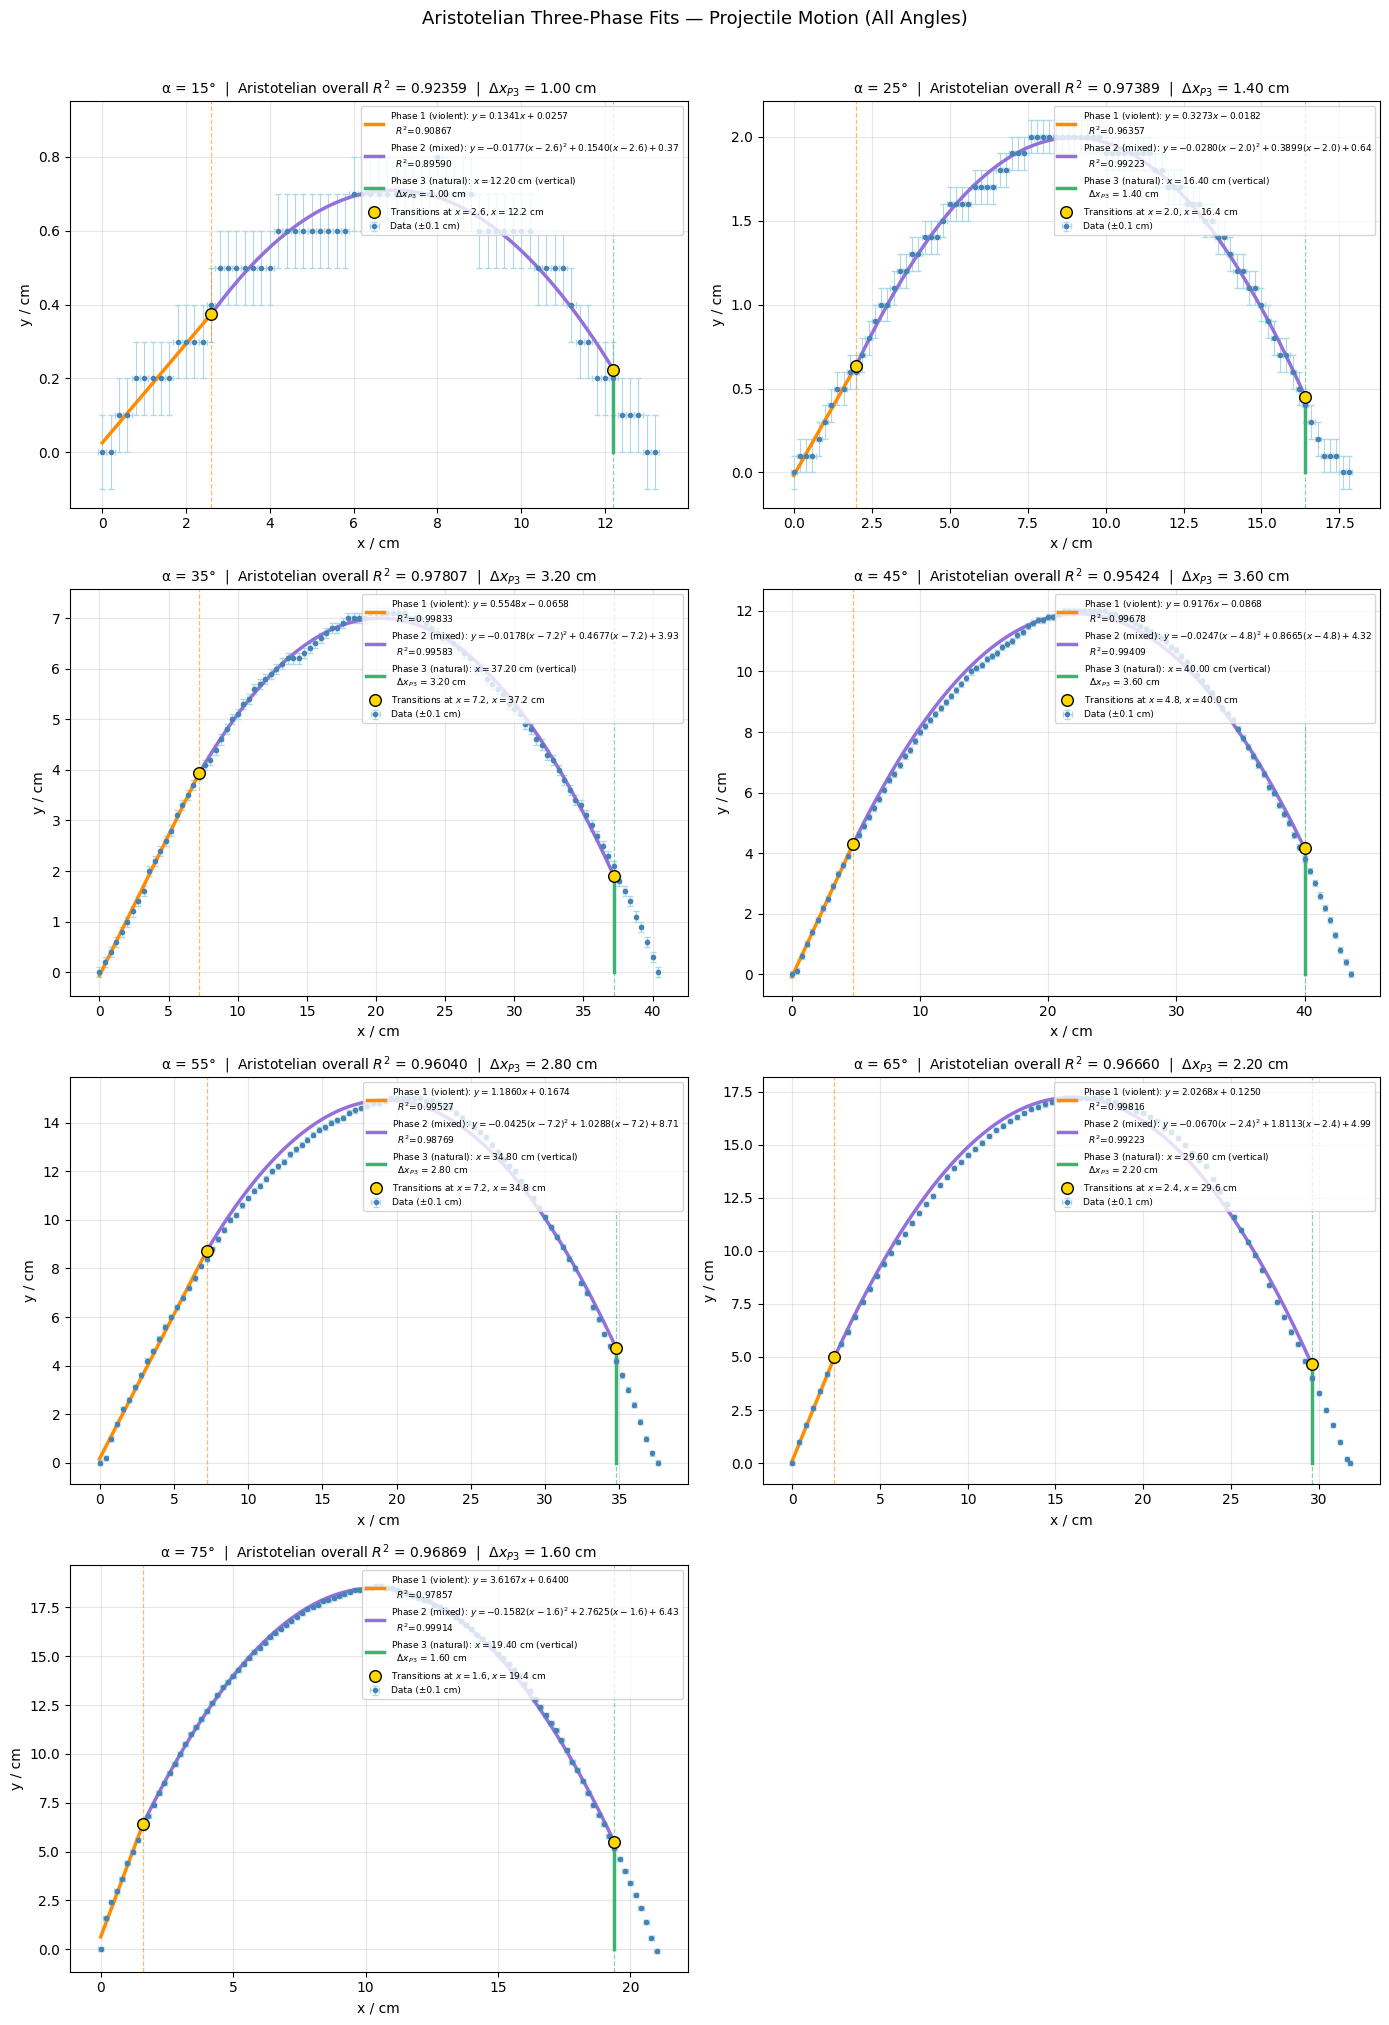

Plot saved to fit_aristotelian.png


In [5]:
fig_aris, axes_aris = plt.subplots(4, 2, figsize=(14, 20))
axes_aris = axes_aris.flatten()

PHASE_COLOURS = {
    'p1': 'darkorange',
    'p2': 'mediumpurple',
    'p3': 'mediumseagreen',
}

for idx, angle in enumerate(ANGLES):
    if angle not in results_aris:
        axes_aris[idx].set_visible(False)
        continue

    csv_path = CSV_DIR / f'alpha_{angle}deg.csv'
    df       = pd.read_csv(csv_path)
    x        = df['x_cm'].to_numpy(dtype=float)
    y        = df['y_cm'].to_numpy(dtype=float)
    r        = results_aris[angle]
    i1, i2   = r['i1'], r['i2']
    x_t1, y_t1, x_t2, y_t2 = r['x_t1'], r['y_t1'], r['x_t2'], r['y_t2']

    ax = axes_aris[idx]

    # Data with error bars
    ax.errorbar(x, y, xerr=SIGMA_XY, yerr=SIGMA_XY,
                fmt='o', ms=3, color='steelblue', ecolor='lightblue',
                elinewidth=0.8, capsize=2, label='Data (±0.1 cm)', zorder=2)

    # Phase 1: violent — linear fit with 2 free parameters (unconstrained)
    xp1 = np.linspace(x[0], x_t1, 200)
    ax.plot(xp1, linear_func(xp1, r['m1'], r['c1']),
            '-', color=PHASE_COLOURS['p1'], lw=2.5,
            label=f"Phase 1 (violent): $y={r['m1']:.4f}x{r['c1']:+.4f}$\n"
                  f"  $R^2$={r['r2_phase1']:.5f}")

    # Phase 2: mixed — quadratic fit with continuity constraint at (x_t1, y_t1)
    xp2 = np.linspace(x_t1, x_t2, 300)
    ax.plot(xp2, eval_p2(xp2, r['a2'], r['b2_s'], x_t1, y_t1),
            '-', color=PHASE_COLOURS['p2'], lw=2.5,
            label=f"Phase 2 (mixed): $y={r['a2']:.4f}(x-{x_t1:.1f})^2{r['b2_s']:+.4f}(x-{x_t1:.1f})+{y_t1:.2f}$\n"
                  f"  $R^2$={r['r2_phase2']:.5f}")

    # Phase 3: natural — vertical fall with no free parameters (x = x_t2)
    ax.plot([x_t2, x_t2], [y_t2, 0],
            '-', color=PHASE_COLOURS['p3'], lw=2.5,
            label=f"Phase 3 (natural): $x = {x_t2:.2f}$ cm (vertical)\n"
                  f"  $\\Delta x_{{P3}}$ = {r['x_spread_p3']:.2f} cm")

    # Transition markers
    ax.axvline(x_t1, color=PHASE_COLOURS['p1'], lw=0.9, ls='--', alpha=0.6)
    ax.axvline(x_t2, color=PHASE_COLOURS['p3'], lw=0.9, ls='--', alpha=0.6)
    ax.scatter([x_t1, x_t2], [y_t1, y_t2],
               color='gold', edgecolors='black', s=70, zorder=5,
               label=f'Transitions at $x={x_t1:.1f}$, $x={x_t2:.1f}$ cm')

    ax.set_title(f'α = {angle}°  |  Aristotelian overall $R^2$ = {r["r2_full"]:.5f}  |  '
                 f'$\\Delta x_{{P3}}$ = {r["x_spread_p3"]:.2f} cm',
                 fontsize=10)
    ax.set_xlabel('x / cm')
    ax.set_ylabel('y / cm')
    ax.legend(fontsize=6.5, loc='upper right')
    ax.grid(True, alpha=0.3)

axes_aris[-1].set_visible(False)

fig_aris.suptitle('Aristotelian Three-Phase Fits — Projectile Motion (All Angles)',
                  fontsize=13, y=1.01)
fig_aris.tight_layout()
plt.savefig('fit_aristotelian.png', dpi=300, bbox_inches='tight')
plt.show()

print('Plot saved to fit_aristotelian.png')

In [6]:
rows_aris = []
for angle in ANGLES:
    if angle not in results_aris:
        continue
    r = results_aris[angle]
    rows_aris.append({
        'alpha_deg':    angle,
        'x_T1_cm':      r['x_t1'],   'y_T1_cm':  r['y_t1'],
        'x_T2_cm':      r['x_t2'],   'y_T2_cm':  r['y_t2'],
        # Phase 1: y = m1*x + c1
        'm1':           r['m1'],     'sig_m1':   r['sm1'],
        'c1':           r['c1'],     'sig_c1':   r['sc1'],
        'R2_phase1':    r['r2_phase1'],
        # Phase 2: y = a2*(x-x_T1)^2 + b2*(x-x_T1) + y_T1  [continuity form]
        'a2':           r['a2'],     'sig_a2':   r['sa2'],
        'b2':           r['b2_s'],   'sig_b2':   r['sb2_s'],
        'R2_phase2':    r['r2_phase2'],
        # Phase 3: x = x_T2 (no free parameters)
        'Delta_x_P3':   r['x_spread_p3'],
        # Overall
        'R2_full':      r['r2_full'],
    })

summary_aris_df = pd.DataFrame(rows_aris).set_index('alpha_deg')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.5f}'.format)
display(summary_aris_df)

summary_aris_df.to_csv('summary_aristotelian.csv')
print('Summary saved to summary_aristotelian.csv')

,x_T1_cm,y_T1_cm,x_T2_cm,y_T2_cm,m1,sig_m1,c1,sig_c1,R2_phase1,a2,sig_a2,b2,sig_b2,R2_phase2,Delta_x_P3,R2_full
alpha_deg,,,,,,,,,,,,,,,,
15,2.60000,0.37429,12.20000,0.22401,0.13407,0.03315,0.02571,0.05071,0.90867,-0.01767,0.00137,0.15395,0.01026,0.89590,1.00000,0.92359
25,2.00000,0.63636,16.40000,0.45114,0.32727,0.04767,-0.01818,0.05641,0.96357,-0.02797,0.00050,0.38986,0.00561,0.99223,1.40000,0.97389
35,7.20000,3.92895,37.20000,1.90642,0.55482,0.01047,-0.06579,0.04413,0.99833,-0.01784,0.00011,0.46770,0.00264,0.99583,3.20000,0.97807
45,4.80000,4.31758,40.00000,4.16645,0.91758,0.01853,-0.08681,0.05241,0.99678,-0.02474,0.00008,0.86648,0.00208,0.99409,3.60000,0.95424
55,7.20000,8.70632,34.80000,4.70843,1.18596,0.01047,0.16737,0.04413,0.99527,-0.04253,0.00014,1.02884,0.00299,0.98769,2.80000,0.96040
65,2.40000,4.98929,29.60000,4.67477,2.02679,0.04725,0.12500,0.06814,0.99816,-0.06702,0.00014,1.81132,0.00306,0.99223,2.20000,0.96660
75,1.60000,6.42667,19.40000,5.46921,3.61667,0.06455,0.64000,0.06146,0.97857,-0.15822,0.00030,2.76252,0.00409,0.99914,1.60000,0.96869


Summary saved to summary_aristotelian.csv


---

## Extended Model Comparison

All three models are compared by overall $R^2$:

| Model | Description | Free parameters |
|-------|-------------|-----------------|
| **Single parabola** | $y = ax^2 + bx + c$ over full trajectory | 3 |
| **Piecewise parabolic** | Two quadratics split at peak; peak fixed by data | 6 |
| **Aristotelian** | Linear → Parabola (continuous) → Vertical; splits found by grid search | 5 + 2 optimised splits |

> **Note on Aristotelian $R^2$:** Phase 3 has no $y$-from-$x$ prediction (the model asserts $x = x_{T2}$ with $y$ undefined). For comparability, Phase 3 is assigned $\hat{y} = y_{T2}$ (constant). This fairly penalises the model for the descending $y$ values it cannot explain, tending to suppress $R^2$ for high angles where Phase 3 covers more of the trajectory.

> **Parameter count note:** The Aristotelian model uses 5 fitted coefficients but has 2 extra free split points found by grid search, so its effective complexity is higher than the table suggests.

In [7]:
rows_comp = []

for angle in ANGLES:
    if angle not in results:
        continue

    csv_path = CSV_DIR / f'alpha_{angle}deg.csv'
    df = pd.read_csv(csv_path)
    x = df['x_cm'].to_numpy(dtype=float)
    y = df['y_cm'].to_numpy(dtype=float)

    _, _, r2_single = fit_parabola(x, y, SIGMA_XY)
    r2_p = results[angle]['r2_full']
    r2_aris = results_aris[angle]['r2_full'] if angle in results_aris else np.nan

    rows_comp.append({
        'alpha_deg': angle,
        'R2_single': r2_single,
        'R2_parabola': r2_p,
        'R2_aristotelian': r2_aris,
        'delta R2_(parabola - single)': r2_p - r2_single,
        'delta R2_(aristotelian - single)': r2_aris - r2_single
    })

comparison_df = pd.DataFrame(rows_comp).set_index('alpha_deg')

display(comparison_df.round(6))

,R2_single,R2_parabola,R2_aristotelian,delta R2_(parabola - single),delta R2_(aristotelian - single)
alpha_deg,,,,,
15,0.95379,0.97269,0.92359,0.01890,-0.03020
25,0.99309,0.99477,0.97389,0.00167,-0.01920
35,0.99779,0.99894,0.97807,0.00115,-0.01971
45,0.99688,0.99985,0.95424,0.00297,-0.04264
55,0.99396,0.99981,0.96040,0.00585,-0.03356
65,0.99678,0.99911,0.96660,0.00232,-0.03018
75,0.99894,0.99926,0.96869,0.00032,-0.03025
